C:\Users\박세은\AppData\Local\Temp\ipykernel_19412\1780000147.py:64: UserWarning: Input data is complex, switching to return_onesided=False
  f, t_spec, Zxx = signal.stft(noisy_sig, fs, nperseg=64)


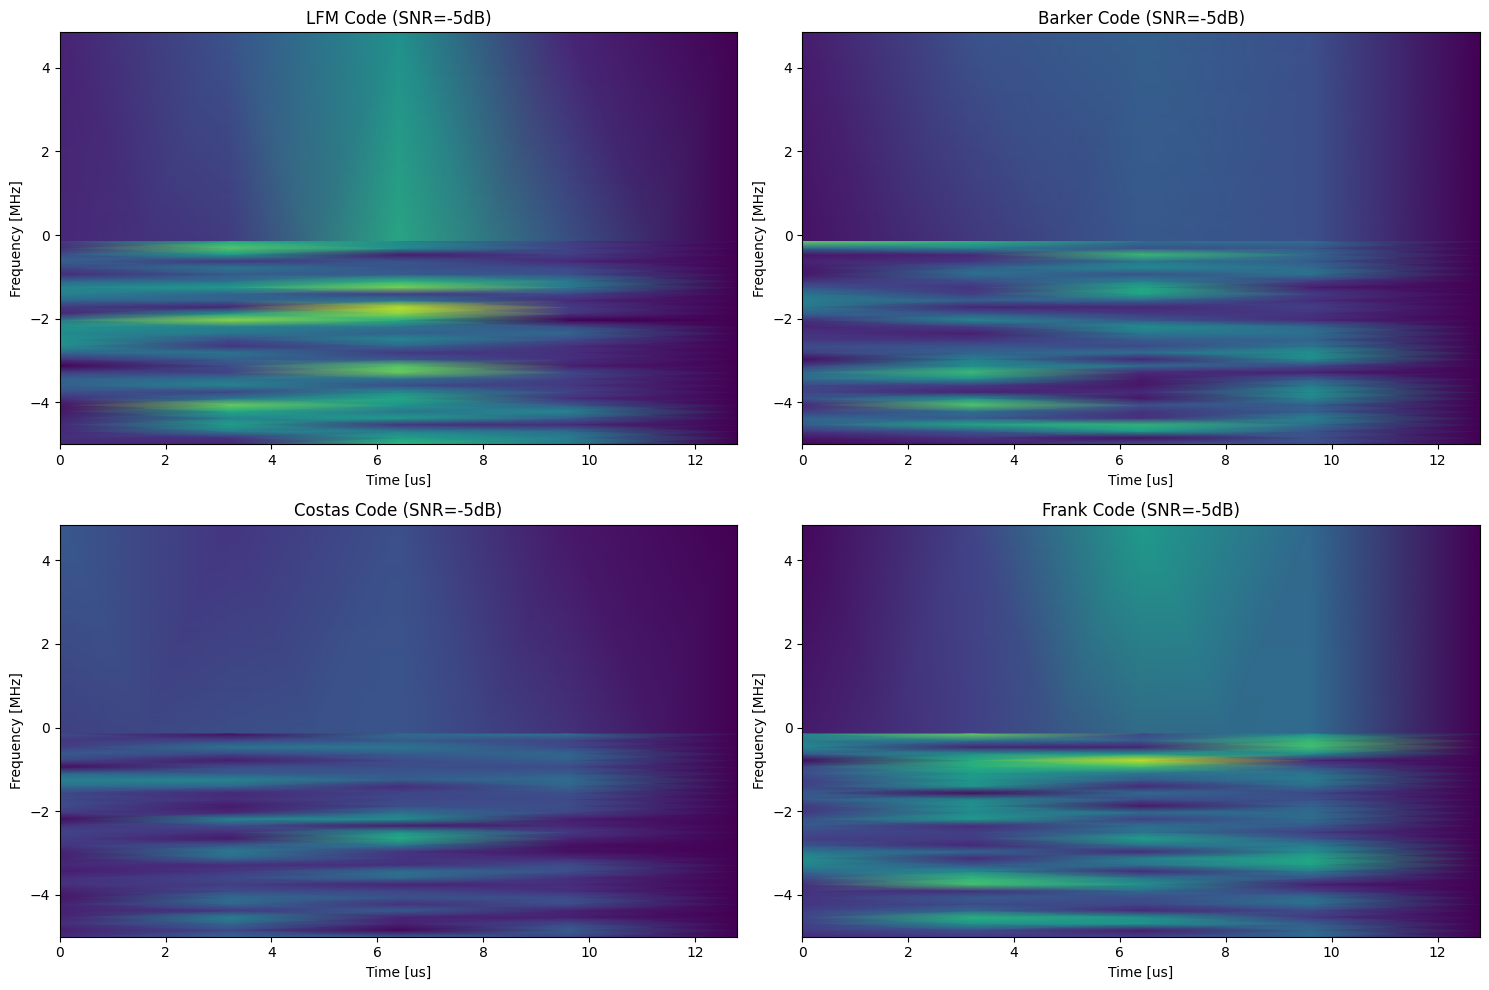

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. 설정 파라미터
fs = 10e6       # 샘플링 주파수 (10 MHz)
T = 10e-6       # 펄스 지속 시간 (10 us)
t = np.arange(0, T, 1/fs) # 시간 축
n_samples = len(t)

# 2. 레이더 파형 생성 함수 (4가지 클래스)
def generate_signals():
    signals = {}
    
    # (1) LFM (Linear Frequency Modulation) - 주파수가 쭉 올라가는 선
    f_start = 1e6
    f_end = 4e6
    signals['LFM'] = np.exp(1j * 2 * np.pi * (f_start * t + (f_end - f_start) / (2 * T) * t**2))

    # (2) Barker Code (Phase Modulation) - 위상이 180도씩 바뀌는 패턴
    code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]) # Barker 13
    chip_width = int(n_samples / len(code))
    phase = np.zeros(n_samples)
    for i, bit in enumerate(code):
        phase[i*chip_width:(i+1)*chip_width] = 0 if bit == 1 else np.pi
    signals['Barker'] = np.exp(1j * phase)

    # (3) Costas Code (Frequency Hopping) - 주파수가 계단식으로 점프
    freqs = np.array([2, 4, 8, 5, 10, 6, 7, 3, 9, 1]) * 1e5 # 임의의 주파수 패턴
    hop_width = int(n_samples / len(freqs))
    costas_sig = np.zeros(n_samples, dtype=complex)
    for i, f in enumerate(freqs):
        t_segment = t[i*hop_width:(i+1)*hop_width]
        costas_sig[i*hop_width:(i+1)*hop_width] = np.exp(1j * 2 * np.pi * f * t_segment)
    signals['Costas'] = costas_sig
    
    # (4) Frank Code (Polyphase Modulation) - 위상이 계단식으로 변함
    M = 4 # M*M = 16 phases
    frank_len = M * M
    chip_width = int(n_samples / frank_len)
    phase = np.zeros(n_samples)
    for i in range(M):
        for j in range(M):
            idx = i * M + j
            phase[idx*chip_width:(idx+1)*chip_width] = 2 * np.pi * i * j / M
    signals['Frank'] = np.exp(1j * phase)

    return signals

# 3. 데이터 생성 및 시각화 (STFT)
radar_signals = generate_signals()

plt.figure(figsize=(15, 10))

for i, (name, sig) in enumerate(radar_signals.items()):
    # 잡음 추가 (SNR -5dB: 신호보다 잡음이 더 큼)
    snr_db = -5
    noise = (np.random.randn(len(sig)) + 1j * np.random.randn(len(sig))) / np.sqrt(2)
    sig_power = np.mean(np.abs(sig)**2)
    noise_power = sig_power / (10**(snr_db/10))
    noisy_sig = sig + np.sqrt(noise_power) * noise
    
    # STFT (Short-Time Fourier Transform) -> 이미지 변환
    f, t_spec, Zxx = signal.stft(noisy_sig, fs, nperseg=64)
    
    # 그래프 그리기
    plt.subplot(2, 2, i+1)
    plt.pcolormesh(t_spec*1e6, f/1e6, np.abs(Zxx), shading='gouraud')
    plt.title(f"{name} Code (SNR={snr_db}dB)")
    plt.ylabel('Frequency [MHz]')
    plt.xlabel('Time [us]')

plt.tight_layout()
plt.show()